In [1]:
#Load data, look at it (head, info, describe, histograms).
from pathlib import Path
import pandas as pd
import numpy as np
import tarfile
import urllib.request

def load_information():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_data = load_information()

In [2]:
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

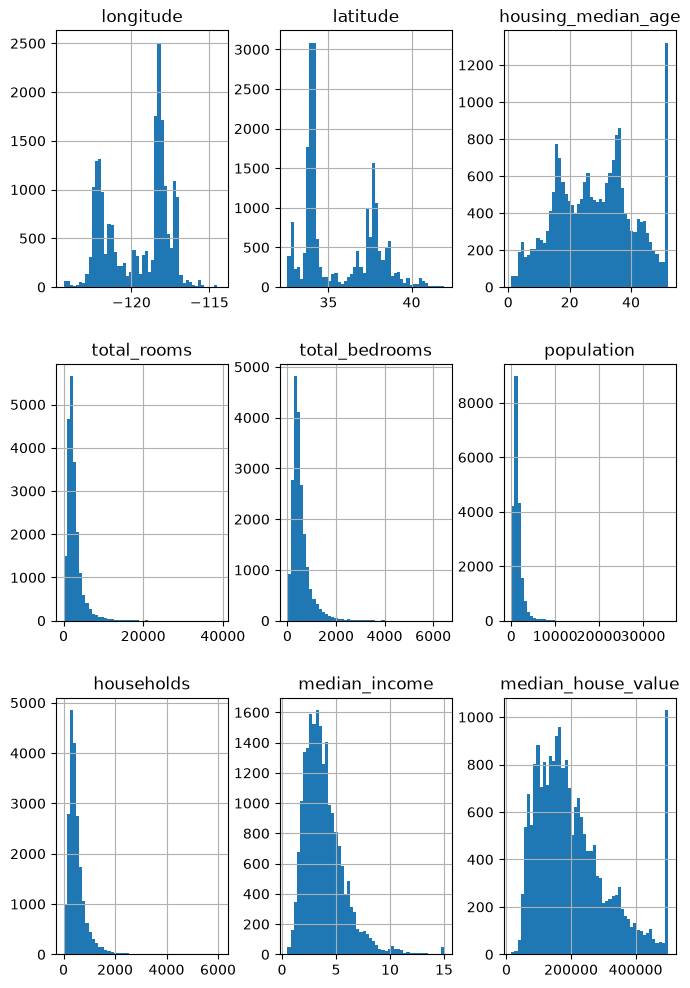

In [5]:
housing_data.hist(bins=50, figsize=(8, 12))

<Axes: xlabel='median_income', ylabel='median_house_value'>

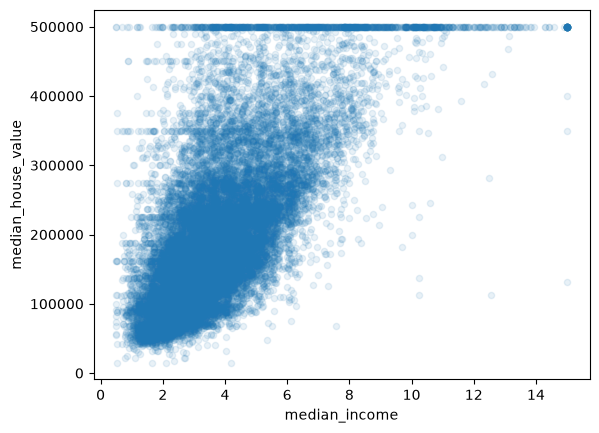

In [6]:
housing_data.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

<Axes: xlabel='latitude', ylabel='longitude'>

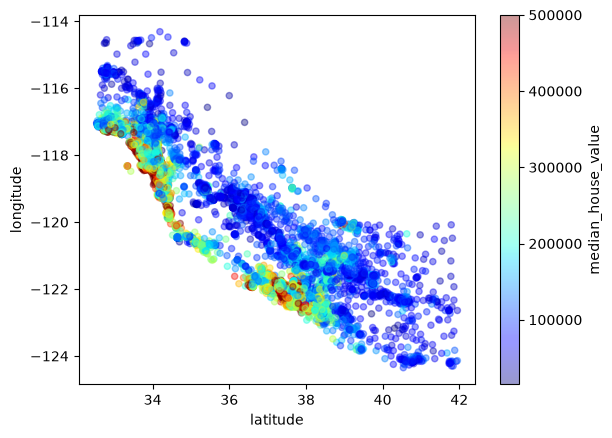

In [7]:
housing_data.plot(kind="scatter", x="latitude", y="longitude",
                  c="median_house_value", cmap="jet", colorbar=True, alpha=0.4)

In [8]:
housing_data.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [9]:
#Split train/test first (stratified if a key feature matters). Never touch test again
from sklearn.model_selection import train_test_split

housing_data["income_cat"] = pd.cut(housing_data["median_income"], bins=(0., 1.5, 3., 4.5, 6., np.inf), labels=(1, 2, 3, 4, 5))

strat_train_set, strat_test_set = train_test_split(housing_data, test_size=0.2, stratify=housing_data["income_cat"], random_state=42)
strat_train_set, strat_test_set = strat_train_set.drop("income_cat", axis=1), strat_test_set.drop("income_cat", axis=1)

In [10]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [11]:
#Explore the train set(correlations, plot)
housing.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND


In [12]:
housing.join(housing_labels).corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

In [13]:
# housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
# housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
# housing["people_per_house"] = housing["population"] / housing["households"]

In [14]:
# housing.join(housing_labels).corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmean_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmean_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmean_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [16]:
clus_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)

In [17]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.utils.validation import check_is_fitted

class KNNIncomeFeature(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self, X, y=None):
        X = np.asarray(X)
        coords = X[:, :2]
        income = X[:, 2]
        self.knn_ = KNeighborsRegressor(n_neighbors=self.n_neighbors)
        self.knn_.fit(coords, income)
        return self

    def transform(self, X):
        check_is_fitted(self)
        coords = np.asarray(X)[:, :2]
        return self.knn_.predict(coords).reshape(-1, 1)

    def get_feature_names_out(self, names=None):
        return np.array(["knn_income"])

In [18]:
#Write the preprocessing pipeline: impute, then transform/scale, and encode categories
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("ratio", FunctionTransformer(column_ratio, feature_names_out=ratio_name)),
    ("scale", StandardScaler())
])

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
"total_bedrooms", "population", "households", "median_income"]

cat_attribs = ["ocean_proximity"]

preprocessing = ColumnTransformer([
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("bedrooms_ratio", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("geography", clus_simil, ["latitude", "longitude"]),
    ("knn_income", KNNIncomeFeature(), ["latitude", "longitude", "median_income"]),
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

prepared = preprocessing.fit_transform(housing)
print(prepared.shape)
preprocessing.get_feature_names_out()

(16512, 27)


array(['rooms_per_house__ratio', 'bedrooms_ratio__ratio',
       'people_per_house__ratio', 'geography__Cluster 0 similarity',
       'geography__Cluster 1 similarity',
       'geography__Cluster 2 similarity',
       'geography__Cluster 3 similarity',
       'geography__Cluster 4 similarity',
       'geography__Cluster 5 similarity',
       'geography__Cluster 6 similarity',
       'geography__Cluster 7 similarity',
       'geography__Cluster 8 similarity',
       'geography__Cluster 9 similarity', 'knn_income__knn_income',
       'num__longitude', 'num__latitude', 'num__housing_median_age',
       'num__total_rooms', 'num__total_bedrooms', 'num__population',
       'num__households', 'num__median_income',
       'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND',
       'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY',
       'cat__ocean_proximity_NEAR OCEAN'], dtype=object)

In [19]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(prepared, housing_labels)
some_new_data = preprocessing.transform(housing.iloc[:5])
lin_predictions = lin_reg.predict(some_new_data)

compare_table = zip(lin_predictions, housing_labels.iloc[:5].values)
print(list(compare_table))

[(np.float64(293578.94189398445), np.float64(458300.0)), (np.float64(335033.4818733396), np.float64(483800.0)), (np.float64(133441.60328593777), np.float64(101700.0)), (np.float64(90264.97135865537), np.float64(96100.0)), (np.float64(316127.4258270377), np.float64(361800.0))]


In [20]:
from sklearn.metrics import root_mean_squared_error
lin_preds = lin_reg.predict(prepared)
print(root_mean_squared_error(housing_labels, lin_preds))

62907.201032626304


In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

forest_reg_with_prep = Pipeline([
    ("preprocess", preprocessing),
    ("select_features", SelectFromModel(RandomForestRegressor(n_estimators=100, n_jobs=10, random_state=42),
                        threshold="median")),
    ("rand_forest_reg", RandomForestRegressor(n_jobs=-1, random_state=42))
])
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(prepared, housing_labels)

forest_preds = forest_reg.predict(prepared)
print(root_mean_squared_error(housing_labels, forest_preds))

16902.383192075657


In [22]:
forest_reg_with_prep.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocess', 'select_features', 'rand_forest_reg', 'preprocess__n_jobs', 'preprocess__remainder', 'preprocess__sparse_threshold', 'preprocess__transformer_weights', 'preprocess__transformers', 'preprocess__verbose', 'preprocess__verbose_feature_names_out', 'preprocess__rooms_per_house', 'preprocess__bedrooms_ratio', 'preprocess__people_per_house', 'preprocess__geography', 'preprocess__knn_income', 'preprocess__num', 'preprocess__cat', 'preprocess__rooms_per_house__memory', 'preprocess__rooms_per_house__steps', 'preprocess__rooms_per_house__transform_input', 'preprocess__rooms_per_house__verbose', 'preprocess__rooms_per_house__impute', 'preprocess__rooms_per_house__ratio', 'preprocess__rooms_per_house__scale', 'preprocess__rooms_per_house__impute__add_indicator', 'preprocess__rooms_per_house__impute__copy', 'preprocess__rooms_per_house__impute__fill_value', 'preprocess__rooms_per_house__impute__keep_empty_features', 'preproces

In [23]:
from sklearn.model_selection import cross_val_score

forest_scores = -cross_val_score(forest_reg, prepared, housing_labels,
                          scoring="neg_root_mean_squared_error", cv=10, n_jobs=10)
print(pd.Series(forest_scores).describe())

count       10.000000
mean     45619.880894
std       1360.160857
min      43353.162990
25%      44740.930199
50%      45848.385427
75%      46377.747904
max      48007.413109
dtype: float64


In [24]:
lin_scores = -cross_val_score(lin_reg, prepared, housing_labels,
                          scoring="neg_root_mean_squared_error", cv=10)
print(pd.Series(lin_scores).describe())

count       10.000000
mean     63139.943174
std       1120.796747
min      61289.705660
25%      62407.823198
50%      62838.559404
75%      64222.500305
max      64616.368123
dtype: float64


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    "preprocess__geography__n_clusters": randint(low=3, high=50),
    "select_features__threshold": ["median", "mean", "0.5*mean"],
    "rand_forest_reg__max_features": randint(low=2, high=10),
    "preprocess__num__impute__strategy": ["median", "mean"],
    "preprocess__geography__gamma": [0.1, 0.5, 1.0]
}

rand_search = RandomizedSearchCV(forest_reg_with_prep, param_distributions=param_distributions, n_iter=10, cv=3,
                                 scoring="neg_root_mean_squared_error", random_state=42, n_jobs=10)
rand_search.fit(housing, housing_labels)
print(rand_search.best_params_)

{'preprocess__geography__gamma': 1.0, 'preprocess__geography__n_clusters': 31, 'preprocess__num__impute__strategy': 'median', 'rand_forest_reg__max_features': 4, 'select_features__threshold': 'median'}


In [26]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     "preprocess__geography__n_clusters": [10, 15, 20],
#     "rand_forest_reg__max_features": [6, 8, 10]
# }

# grid_search = GridSearchCV(forest_reg_with_prep, param_grid=param_grid,
#                            scoring="neg_root_mean_squared_error", cv=3)
# grid_search.fit(housing, housing_labels)
# print(grid_search.best_estimator_)

In [27]:
final_model = rand_search.best_estimator_

In [28]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)
print(root_mean_squared_error(y_test, final_predictions))
print(-rand_search.best_score_)

43177.212088753644
43650.72280782627


In [29]:
import joblib
joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

In [30]:
#Exercise 1
X_small = housing.iloc[:5000]
y_small = housing_labels.iloc[:5000]

In [31]:
from sklearn.svm import SVR

svr_pipe = Pipeline([
    ("preprocess", preprocessing),
    ("svr", SVR())
])

In [32]:
scores = -cross_val_score(svr_pipe, X_small, y_small,
                          scoring="neg_root_mean_squared_error", cv=3)
print(scores.mean())

119688.3434736519


In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"svr__kernel": ["linear"], "svr__C": [1000, 10000, 30000, 100000]},
    {"svr__kernel": ["rbf"], "svr__C": [1000, 10000, 100000],
     "svr__gamma": [0.01, 0.1, 1.0]}
]

svr_search = GridSearchCV(svr_pipe, param_grid=param_grid, cv=3,
                          scoring="neg_root_mean_squared_error", n_jobs=10)
svr_search.fit(X_small, y_small)
print(svr_search.best_params_, -svr_search.best_score_)

{'svr__C': 100000, 'svr__gamma': 0.1, 'svr__kernel': 'rbf'} 53550.85494567669


In [ ]:
#Exercise 3
class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True, with_std=True):
        self.with_mean = with_mean

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape(1)
        return self

    def transform(self, X, y=None):
        check_is_fitted(X)
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.scaler_

    def inverse_transform(self, X):
        check_is_fitted(X)
        return X * self.scaler_ + self.mean_

In [ ]:
data = housing[["median_income"], ["housing_median_age"]]
scaler = StandardScalerClone()
scaler.inverse_transform(scaler.fit_transform(data))